In [4]:
import seaborn as sns
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define the DATA_DIRECTORY and FIGURE_DIRECTORY
HERE = os. getcwd()
DATA_DIRECTORY = os.path.abspath(os.path.join(HERE, os.pardir, 'data'))
FIGURE_DIRECTORY = os.path.abspath(os.path.join(HERE, os.pardir, 'figures'))

In [5]:
wallace_metadata_path = os.path.join(DATA_DIRECTORY, 'raw','Wallace2019', 'metadata.xlsx' )
wallace_metadata_df = pd.read_excel(wallace_metadata_path)
wallace_metadata_df= wallace_metadata_df.sort_values(by=['Cow Code']).dropna(axis=0,how='all').dropna(axis=0, subset=['methane g/d'])
wallace_metadata_df=wallace_metadata_df.loc[wallace_metadata_df['Holstein (1)/Nordic Red(2)'] == 1]
wallace_metadata_df.set_index('Cow Code', inplace=True)
wallace_metadata_df_dropna = wallace_metadata_df.dropna(how='any', axis=1)
wallace_metadata_df_dropna


,Country,Cow ID,Sampling week,Farm/Research site code,ear tag number,Holstein (1)/Nordic Red(2),Days in milk,Lactation number,"Live weight, kg",OM,...,Wolin,Ammonia,Measurement method,methane g/d,BHB,Urea,Cholesterol,Creatinine,Albumin,Haptoglobulin
Cow Code,,,,,,,,,,,,,,,,,,,,,
IT1007,IT,1007.0,2015-04-28 00:00:00,IT2,1747,1.0,140.0,2.0,820.000000,929.382000,...,342.292772,4.443120,GreenFeed,541.439752,1.481700,6.70230,5.750000,86.000000,35.135100,0.5574
IT1008,IT,1008.0,2015-04-28 00:00:00,IT2,1749,1.0,191.0,2.0,780.000000,929.382000,...,350.641191,2.192709,GreenFeed,712.719298,1.140700,6.64290,5.850000,86.000000,33.283800,0.1790
IT1009,IT,1009.0,2015-04-28 00:00:00,IT2,1795,1.0,162.0,2.0,800.000000,929.382000,...,339.788048,4.125754,GreenFeed,582.061333,1.577400,6.02910,5.110000,83.000000,36.729000,0.1704
IT1010,IT,1010.0,2015-04-28 00:00:00,IT2,1804,1.0,182.0,2.0,730.000000,929.382000,...,333.246407,4.760486,GreenFeed,545.326087,2.095500,5.55390,7.030000,87.000000,37.045800,0.1102
IT1011,IT,1011.0,2015-04-28 00:00:00,IT2,1806,1.0,161.0,2.0,735.000000,929.382000,...,321.217220,1.586829,GreenFeed,582.260317,0.885500,5.71230,8.030000,82.000000,34.164900,0.1016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UK95,UK,95.0,2014-02-10 00:00:00,UK1,306,1.0,90.0,2.0,556.166667,938.269725,...,340.850460,3.948218,Robot,414.624804,0.789886,5.77000,7.340265,85.004388,35.412008,0.1445
UK96,UK,96.0,2014-02-10 00:00:00,UK1,343,1.0,83.0,1.0,575.250000,938.269725,...,323.920660,5.334908,Robot,481.940186,0.623116,6.52473,6.448660,105.922152,37.989212,0.1235
UK97,UK,97.0,2014-02-10 00:00:00,UK1,353,1.0,102.0,1.0,572.178571,938.269725,...,326.851504,6.129571,Robot,418.275613,0.568180,4.07983,6.080795,88.506828,36.455162,0.1235


In [9]:
metadata_dropna_path = os.path.join(DATA_DIRECTORY, 'interim','Wallace2019', 'metadata_dropna.xlsx' )
wallace_metadata_df_dropna.to_excel(metadata_dropna_path, header=True, index=True)
wallace_metadata_df_dropna_related= wallace_metadata_df_dropna[['Live weight, kg', 'OM', 'CP', 'NDF',
       'Acid-Hydrolysis EE', 'Starch', 'methane g/d']]

In [10]:
corr = wallace_metadata_df_dropna_related.corr(method='spearman').round(decimals=2)

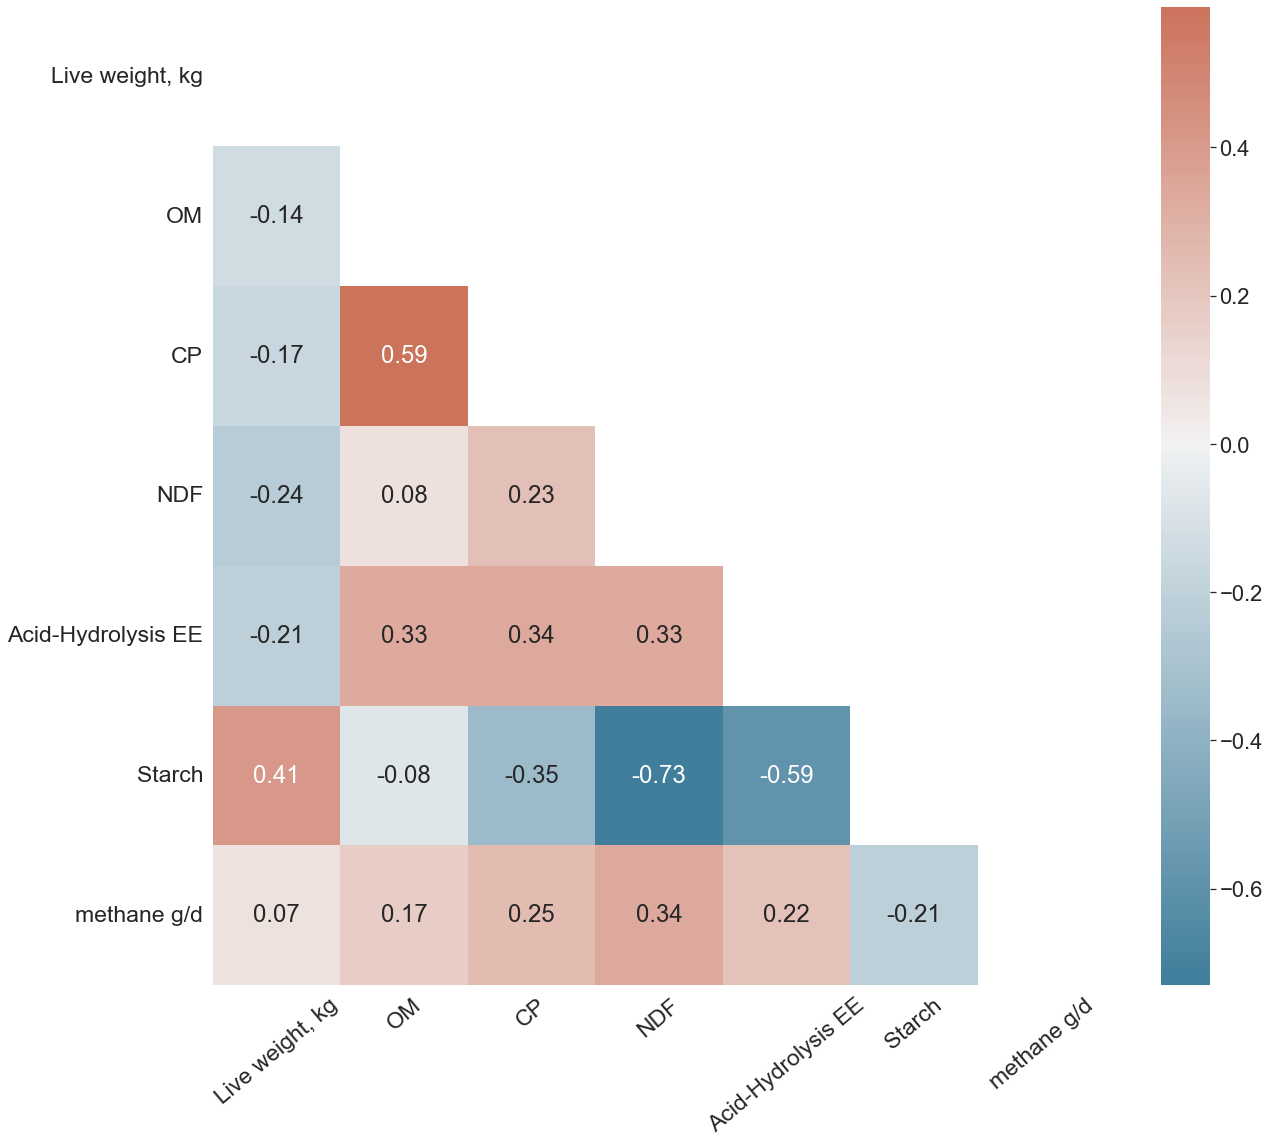

<Figure size 432x288 with 0 Axes>

In [12]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(20, 18))
mask = np.triu(np.ones_like(corr, dtype=bool))

# Configure a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)
f = sns.heatmap(corr, annot=True, mask = mask, cmap=cmap, center=0.00)
sns.set(font_scale=2)

# Generate a mask for upper traingle
ax.set_facecolor("white")
f.set_xticklabels(labels = corr.columns, rotation=40, fontsize=23)
f.set_yticklabels(labels = corr.columns, rotation=0, fontsize=23)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Configure a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap
plt.show()
plt.savefig(os.path.join(FIGURE_DIRECTORY, 'wallace_methane_emission_feed_compositions.png'))
